# Real vs Fake Face Detection

This notebook demonstrates the use of Deep Learning models to distinguish between real and fake (digitally manipulated) face images.

## 1. Dataset Overview

The dataset used is the **Real and Fake Face Detection** dataset from Kaggle.
- **Source:** [Kaggle - Real and Fake Face Detection](https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection)
- **Content:** Images are categorized into "Real" and "Fake". Fake images are created by expert manipulation (photoshopping) of real faces.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Configuration
MODEL_PATH = 'Models/CNNmodel_RealFakeFaceDetection.h5'
DATASET_PATH = 'dataset'
REAL_DIR = os.path.join(DATASET_PATH, 'training_real')
FAKE_DIR = os.path.join(DATASET_PATH, 'training_fake')

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.1


## 2. Load the Model

We load the pre-trained CNN model. Note: `compile=False` is used to avoid version compatibility issues during loading.

In [2]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
model.summary()

c:\Users\Thushan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Inference Function

This function preprocesses an image and returns the prediction score.

In [3]:
def predict_face(image_path):
    # Load and preprocess
    img = load_img(image_path, target_size=(256, 256))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalization
    
    # Predict
    prediction = model.predict(img_array, verbose=0)
    score = prediction[0][0]
    label = 'Real' if score > 0.5 else 'Fake'
    return score, label, img

## 4. Visualize Results

Testing the model on a few samples from the dataset.

Testing Real Samples:


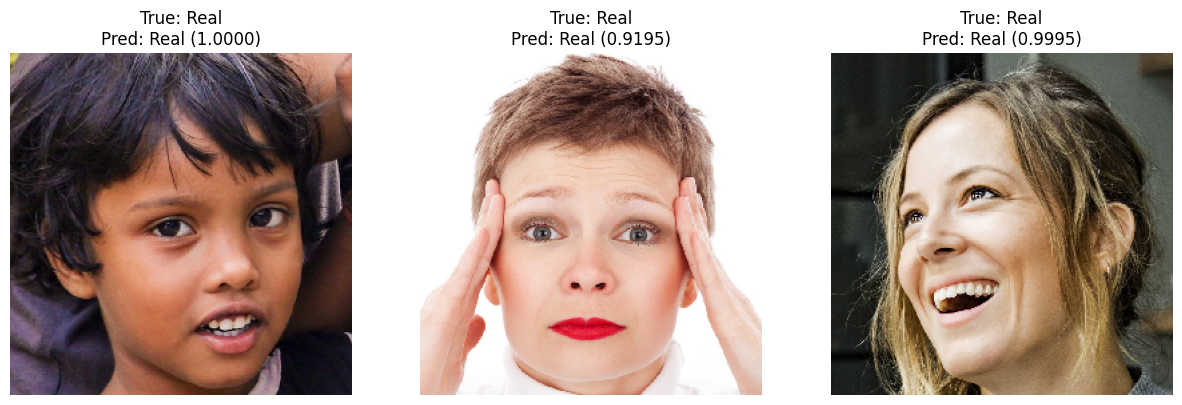

Testing Fake Samples:


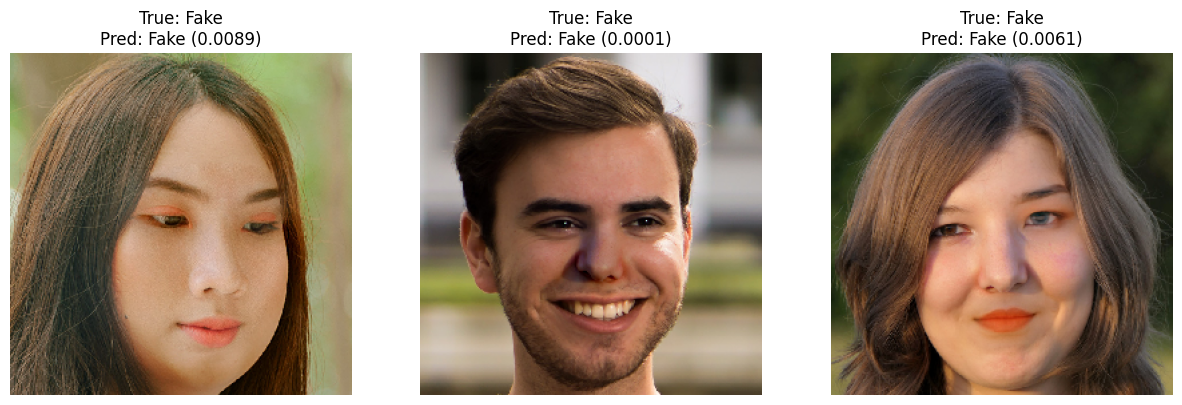

In [4]:
def display_samples(directory, label_name, num_samples=3):
    files = os.listdir(directory)[:num_samples]
    plt.figure(figsize=(15, 5))
    
    for i, file in enumerate(files):
        path = os.path.join(directory, file)
        score, label, img = predict_face(path)
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f'True: {label_name}\nPred: {label} ({score:.4f})')
        plt.axis('off')
    plt.show()

print('Testing Real Samples:')
display_samples(REAL_DIR, 'Real')

print('Testing Fake Samples:')
display_samples(FAKE_DIR, 'Fake')

## 5. Note on VGG16 Model

The `Models/VGG16_RealFakeFaceDetection.h5` model encountered a loading error due to Keras 3 version compatibility (`AttributeError: "str" object has no attribute "quantization_mode"`). This usually requires loading in a Keras 2 environment or re-saving the model in the newer format.